# College of Computing and Informatics, Drexel University
## INFO 323: Cloud Computing and Big Data
### Due: Friday, June 12, 2026
---

## Final Project Report

## Project Title: E-Commerce Customer Behavior Analytics and Churn Prediction

## Team Member(s): Nana Kwasi Owusu
---

# Project Requirements

This final project examines the level of knowledge the students have learned from the course. The project must be done on a cloud computing platform.

## Projects must use cloud computing platforms and technqiues for data analytic problems.

In [ ]:
from pyspark.sql import SparkSession


spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("ColabSpark")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)

print("Spark Version:{}".format(spark.version))

Spark Version:4.0.2


# 1. Problem Definition
---
*(Define the problem that will be solved in this cloud computing project.)*

The rapid growth of online retail has generated an enormous volume of transactional and behavioral data. Understanding how customers interact with digital storefronts, what influences their purchasing decisions, and when they are at risk of disengaging has become a critical strategic priority for e-commerce businesses worldwide. This project uses Google Cloud Platform (GCP) to conduct large-scale exploratory analysis of customer behavior and develop predictive models for customer churn. The project is driven by a central business question: given a customer’s purchase history, browsing activity, and engagement patterns, can we accurately predict whether that customer will stop making purchases within the next 90 days? Addressing this problem requires scalable cloud infrastructure capable of ingesting, storing, and querying tens of millions of records, alongside reproducible machine learning pipelines for model training and evaluation.

Customer churn, defined as the cessation of purchasing activity beyond a specified period, represents a significant challenge in both subscription-based and transactional commerce. Research consistently shows that acquiring a new customer can cost five to seven times more than retaining an existing one (Reichheld & Schefter, 2000). For large e-commerce platforms processing millions of transactions annually, even a small reduction in churn can produce substantial financial impact through improved customer lifetime value and retention rates.

Prior research on churn prediction spans a wide range of methodologies, from traditional Recency-Frequency-Monetary (RFM) segmentation techniques (Blattberg et al., 2008) to survival analysis models (Fader et al., 2005), and more recently, advanced machine learning approaches such as gradient-boosted ensembles and deep sequential neural networks trained on event-stream data (Chen & Guestrin, 2016; Zhang et al., 2019). This project builds upon these foundations by integrating scalable cloud-based analytics with predictive modeling workflows on GCP. In particular, it extends the classical RFM framework by incorporating session-level behavioral features and evaluates the incremental predictive value contributed by each feature group in improving churn prediction performance.


# 2. Data Set
---
*(Describe the origin, format, and  charateristics of the data.)*

The primary dataset is the Online Retail II dataset published by the UCI Machine Learning Repository (Chen et al., 2019). It contains all transactions recorded by a UK-based non-store online retail company between 2009 and 2011, with a total of approximately 1,067,371 rows and 8 attributes per record. The attributes are InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country. It consists of two excel workbooks easily convertible to CSV and available at https://archive.ics.uci.edu/dataset/502/online+retail+ii

To increase dataset scale and introduce geographic diversity, the project will also ingest the Olist Brazilian E-Commerce Public Dataset (Kaggle, 2018), which comprises approximately 100,000 orders placed between 2016 and 2018 across multiple product categories. It is structured as a relational schema of nine CSV files, including orders, order_items, customers, products, sellers, payments, reviews, geolocation, and product category translations.

# 3. Cloud Computing
---
*(Describe the cloud computing platforms and tools used in the project, and explain how they will be applied to address the problem.)*

This project is built entirely on Google Cloud Platform (GCP), using four core services that form an end-to-end pipeline from raw data to deployed prediction.

Google Cloud Storage (GCS) is the staging layer for raw data files. Both the UCI Online Retail II and Olist CSV datasets are uploaded to a GCS bucket and loaded into BigQuery via bq load, keeping source files immutable and separate from processed tables.

BigQuery is the analytical core of the project. All data cleaning, exploratory analysis, and feature engineering are performed in BigQuery using standard SQL — window functions, aggregate functions, and date arithmetic — materialising a final customer-level feature table with approximately 25 engineered RFM and behavioural columns. Models are also trained in-database using BigQuery ML, which supports Logistic Regression and Gradient Boosted Trees classifiers without moving data out of the warehouse, keeping costs and latency low.

Vertex AI Workbench provides the managed JupyterLab notebook environment used for EDA, visualisation (Matplotlib/Seaborn), and model evaluation. It connects directly to BigQuery via the Python client library, pulling query results into Pandas DataFrames for plotting.

Vertex AI AutoML Tabular is used to train a Neural Network model, automatically handling architecture search, normalisation, and hyperparameter tuning. The best-performing model across all three families is deployed to a Vertex AI Prediction endpoint, which exposes a REST API for real-time inference.

For the bonus component, the prediction API is called by a Flask web application containerised with Docker and deployed to Cloud Run, GCP's serverless container platform. Cloud Run scales automatically, incurs no cost at idle, and provides a public HTTPS URL — making it well-suited for a reproducible, shareable course project demo.

# 4. Data Analysis using Cloud Computing
---
*(Use the selected cloud computing platforms and tools to cleanse, wrangle, transform, analyze, and model the data. Document each step, along with the results and findings, ensuring the entire process is reproducible by the TA and instructor.)*

In [3]:
# Run only on Google Colab — skip on Vertex AI Workbench
try:
    from google.colab import auth
    auth.authenticate_user()
    print('Authenticated via Colab')
except ImportError:
    print('Not running in Colab — using ambient credentials')

Authenticated via Colab


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
from google.cloud import bigquery

sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
print('Libraries loaded successfully')

Libraries loaded successfully


In [5]:
#CONFIGURE PROJECT ID HERE
PROJECT_ID  = 'info323-spring-492615'
DATASET_ID  = 'ecommerce'
GCS_BUCKET  = 'gs://info323-no329-spring'

bq = bigquery.Client(project=PROJECT_ID)
print(f'BigQuery client initialised for project: {PROJECT_ID}')

BigQuery client initialised for project: info323-spring-492615


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

# Load Excel workbook
xl = pd.ExcelFile("/content/drive/MyDrive/info323/online_retail_II.xlsx")

# Confirm sheet names
print(xl.sheet_names)

# Read both sheets
df1 = pd.read_excel(xl, sheet_name=0)
df2 = pd.read_excel(xl, sheet_name=1)

# Combine datasets
combined = pd.concat([df1, df2], ignore_index=True)

# Convert InvoiceDate to ISO 8601 format for BigQuery
combined['InvoiceDate'] = pd.to_datetime(combined['InvoiceDate'])
combined['InvoiceDate'] = combined['InvoiceDate'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Convert Customer ID to string without .0 suffix
combined['Customer ID'] = (
    combined['Customer ID']
    .astype('Int64')      # Handles missing values safely
    .astype(str)
    .replace('<NA>', '')
)

#rename column to match BigQuery schema
combined.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

# Export to CSV
combined.to_csv("online_retail_ii.csv", index=False)

print(f"Exported {len(combined):,} rows")
print("CSV file saved as: online_retail_ii.csv")

['Year 2009-2010', 'Year 2010-2011']
Exported 1,067,371 rows
CSV file saved as: online_retail_ii.csv


In [ ]:
from google.colab import files

files.download("online_retail_ii.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create the BigQuery dataset if it does not already exist
ds_ref = bigquery.Dataset(f'{PROJECT_ID}.{DATASET_ID}')
ds_ref.location = 'US'
bq.create_dataset(ds_ref, exists_ok=True)
print(f'Dataset `{DATASET_ID}` ready')

Dataset `ecommerce` ready


In [8]:
# Load UCI Online Retail II
retail_schema = [
    bigquery.SchemaField('InvoiceNo',   'STRING'),
    bigquery.SchemaField('StockCode',   'STRING'),
    bigquery.SchemaField('Description', 'STRING'),
    bigquery.SchemaField('Quantity',    'INTEGER'),
    bigquery.SchemaField('InvoiceDate', 'TIMESTAMP'),
    bigquery.SchemaField('UnitPrice',   'FLOAT'),
    bigquery.SchemaField('CustomerID',  'STRING'),
    bigquery.SchemaField('Country',     'STRING'),
]

job_config = bigquery.LoadJobConfig(
    schema=retail_schema,
    skip_leading_rows=1,
    source_format=bigquery.SourceFormat.CSV,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

uri = f'{GCS_BUCKET}/online_retail_ii.csv'
load_job = bq.load_table_from_uri(uri, f'{PROJECT_ID}.{DATASET_ID}.retail_raw', job_config=job_config)
load_job.result()

table = bq.get_table(f'{PROJECT_ID}.{DATASET_ID}.retail_raw')
print(f'Loaded {table.num_rows:,} rows into `retail_raw`')

Loaded 1,067,371 rows into `retail_raw`


In [9]:
#Load Olist orders
orders_schema = [
    bigquery.SchemaField('order_id',                      'STRING'),
    bigquery.SchemaField('customer_id',                   'STRING'),
    bigquery.SchemaField('order_status',                  'STRING'),
    bigquery.SchemaField('order_purchase_timestamp',      'TIMESTAMP'),
    bigquery.SchemaField('order_approved_at',             'TIMESTAMP'),
    bigquery.SchemaField('order_delivered_carrier_date',  'TIMESTAMP'),
    bigquery.SchemaField('order_delivered_customer_date', 'TIMESTAMP'),
    bigquery.SchemaField('order_estimated_delivery_date', 'TIMESTAMP'),
]

job_config = bigquery.LoadJobConfig(
    schema=orders_schema,
    skip_leading_rows=1,
    source_format=bigquery.SourceFormat.CSV,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

uri = f'{GCS_BUCKET}/olist_orders_dataset.csv'
load_job = bq.load_table_from_uri(uri, f'{PROJECT_ID}.{DATASET_ID}.olist_orders_raw', job_config=job_config)
load_job.result()

table = bq.get_table(f'{PROJECT_ID}.{DATASET_ID}.olist_orders_raw')
print(f'Loaded {table.num_rows:,} rows into `olist_orders_raw`')

Loaded 99,441 rows into `olist_orders_raw`


In [10]:
#Before analysis, the raw data is assessed for quality issues and cleaned entirely within BigQuery SQL. The result is materialised as retail_clean — a permanent, reproducible table.
#Assess raw data quality
sql = '''
SELECT
    COUNT(*)                                          AS total_rows,
    COUNTIF(CustomerID IS NULL)                       AS null_customer_id,
    COUNTIF(STARTS_WITH(InvoiceNo, 'C'))              AS cancellations,
    COUNTIF(UnitPrice <= 0)                           AS zero_or_neg_price,
    COUNTIF(Quantity <= 0)                            AS zero_or_neg_qty,
    ROUND(100 * COUNTIF(CustomerID IS NULL)
          / COUNT(*), 2)                              AS pct_null_customer
FROM `{PROJECT_ID}.{DATASET_ID}.retail_raw`
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

quality = bq.query(sql).to_dataframe()
print('Raw data quality summary:')
quality

Raw data quality summary:


,total_rows,null_customer_id,cancellations,zero_or_neg_price,zero_or_neg_qty,pct_null_customer
0,1067371,243007,19494,6207,22950,22.77


In [11]:
#Materialise cleaned table
# Rules applied:
#   - Exclude null CustomerID (anonymous sessions)
#   - Exclude cancellation invoices (InvoiceNo starts with 'C')
#   - Exclude UnitPrice <= 0 (samples / errors)
#   - Exclude Quantity <= 0
#   - Add derived column: LineTotal = Quantity * UnitPrice

sql = '''
CREATE OR REPLACE TABLE `{PROJECT_ID}.{DATASET_ID}.retail_clean` AS
SELECT
    InvoiceNo,
    StockCode,
    TRIM(Description)                         AS Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    SAFE_CAST(Quantity AS FLOAT64) * UnitPrice AS LineTotal
FROM `{PROJECT_ID}.{DATASET_ID}.retail_raw`
WHERE CustomerID IS NOT NULL
  AND NOT STARTS_WITH(InvoiceNo, 'C')
  AND UnitPrice > 0
  AND Quantity > 0
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

bq.query(sql).result()
table = bq.get_table(f'{PROJECT_ID}.{DATASET_ID}.retail_clean')
print(f'retail_clean created with {table.num_rows:,} rows')

retail_clean created with 805,549 rows


In [12]:
#Verify cleaning results
sql = '''
SELECT
    COUNT(*)                              AS total_rows,
    COUNT(DISTINCT CustomerID)            AS unique_customers,
    COUNT(DISTINCT InvoiceNo)             AS unique_invoices,
    COUNT(DISTINCT StockCode)             AS unique_products,
    MIN(InvoiceDate)                      AS earliest_date,
    MAX(InvoiceDate)                      AS latest_date,
    ROUND(SUM(LineTotal), 2)              AS total_revenue
FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

summary = bq.query(sql).to_dataframe()
print('Cleaned dataset summary:')
summary

Cleaned dataset summary:


,total_rows,unique_customers,unique_invoices,unique_products,earliest_date,latest_date,total_revenue
0,805549,5878,36969,4631,2009-12-01 07:45:00+00:00,2011-12-09 12:50:00+00:00,17743429.18


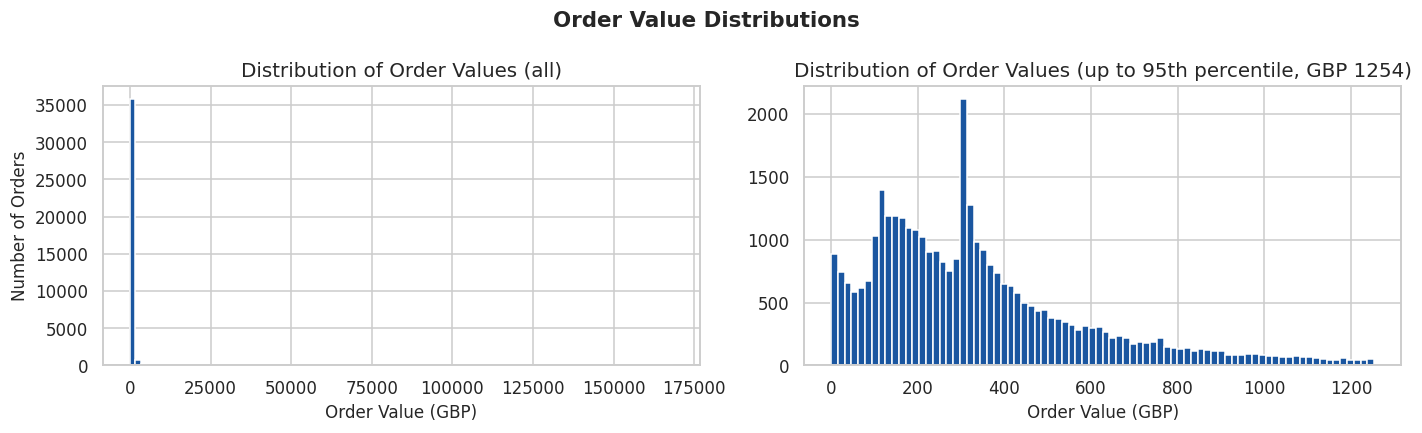

count     36969.00
mean        479.95
std        1374.99
min           0.38
25%         160.80
50%         305.25
75%         489.26
max      168469.60
Name: order_value, dtype: float64


In [13]:
#Distribution of order values
sql = '''
SELECT InvoiceNo, SUM(LineTotal) AS order_value
FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
GROUP BY InvoiceNo
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

order_vals = bq.query(sql).to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(order_vals['order_value'], bins=100, color='#1A56A0', edgecolor='white')
axes[0].set_xlabel('Order Value (GBP)')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Distribution of Order Values (all)')

p95 = order_vals['order_value'].quantile(0.95)
axes[1].hist(order_vals[order_vals['order_value'] <= p95]['order_value'],
             bins=80, color='#1A56A0', edgecolor='white')
axes[1].set_xlabel('Order Value (GBP)')
axes[1].set_title(f'Distribution of Order Values (up to 95th percentile, GBP {p95:.0f})')

plt.suptitle('Order Value Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(order_vals['order_value'].describe().round(2))

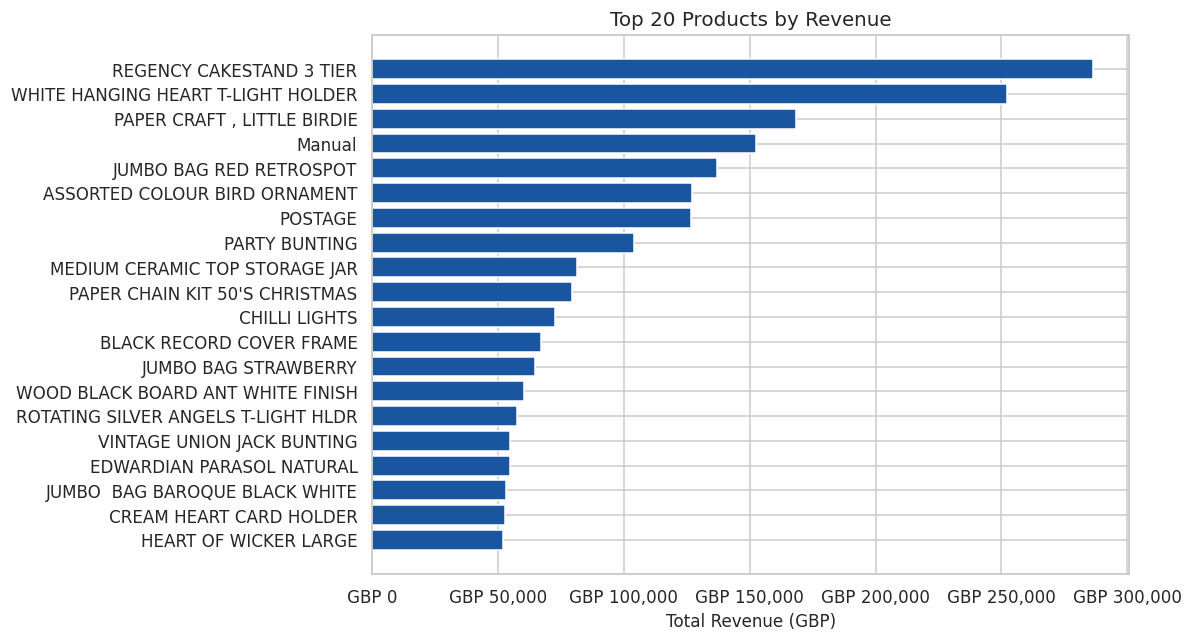

,Description,num_orders,units_sold,total_revenue
0,REGENCY CAKESTAND 3 TIER,3317,24899,286486.30
1,WHITE HANGING HEART T-LIGHT HOLDER,4888,93640,252072.46
2,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60
3,Manual,620,9803,152340.57
4,JUMBO BAG RED RETROSPOT,2612,75759,136980.08
5,ASSORTED COLOUR BIRD ORNAMENT,2652,79913,127074.17
6,POSTAGE,1803,5333,126563.04
7,PARTY BUNTING,2077,23607,103880.23
8,MEDIUM CERAMIC TOP STORAGE JAR,195,77916,81416.73
9,PAPER CHAIN KIT 50'S CHRISTMAS,1691,29477,79594.33


In [14]:
#Top 20 Products by revenue
sql = '''
SELECT
    Description,
    COUNT(DISTINCT InvoiceNo)  AS num_orders,
    SUM(Quantity)              AS units_sold,
    ROUND(SUM(LineTotal), 2)   AS total_revenue
FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 20
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

top_products = bq.query(sql).to_dataframe()

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_products['Description'][::-1], top_products['total_revenue'][::-1],
        color='#1A56A0', edgecolor='white')
ax.set_xlabel('Total Revenue (GBP)')
ax.set_title('Top 20 Products by Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
plt.tight_layout()
plt.show()
top_products.head(10)

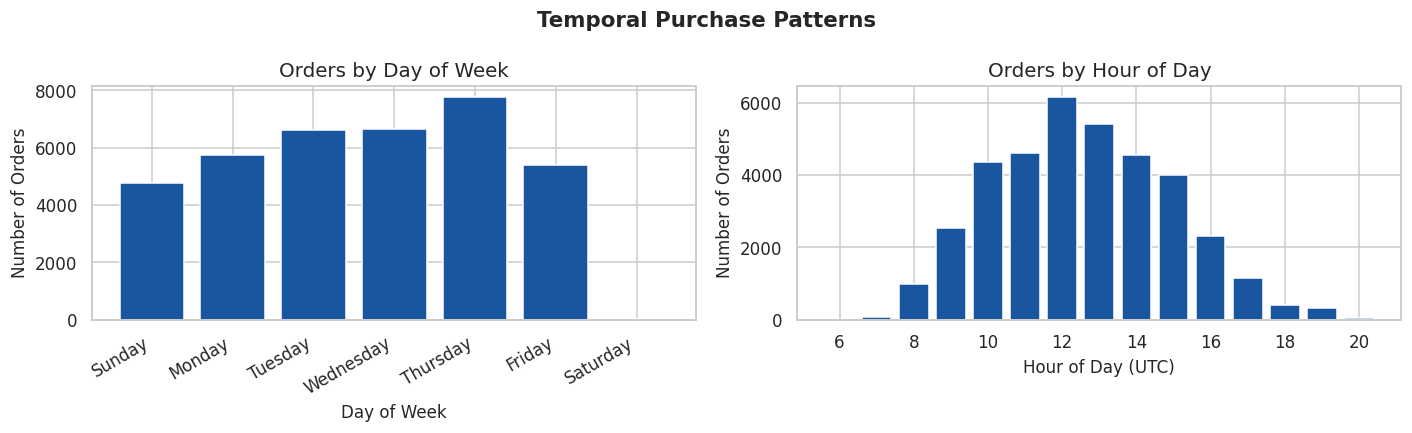

In [15]:
#Temporal Patterns — Day of Week and Hour of Day
sql_dow = '''
SELECT
    FORMAT_DATE('%A', DATE(InvoiceDate))    AS day_of_week,
    EXTRACT(DAYOFWEEK FROM InvoiceDate)     AS dow_num,
    COUNT(DISTINCT InvoiceNo)               AS num_orders
FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
GROUP BY day_of_week, dow_num
ORDER BY dow_num
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

sql_hod = '''
SELECT
    EXTRACT(HOUR FROM InvoiceDate) AS hour_of_day,
    COUNT(DISTINCT InvoiceNo)      AS num_orders
FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
GROUP BY hour_of_day
ORDER BY hour_of_day
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

dow = bq.query(sql_dow).to_dataframe()
hod = bq.query(sql_hod).to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(dow['day_of_week'], dow['num_orders'], color='#1A56A0', edgecolor='white')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Orders by Day of Week')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

axes[1].bar(hod['hour_of_day'], hod['num_orders'], color='#1A56A0', edgecolor='white')
axes[1].set_xlabel('Hour of Day (UTC)')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Orders by Hour of Day')

plt.suptitle('Temporal Purchase Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

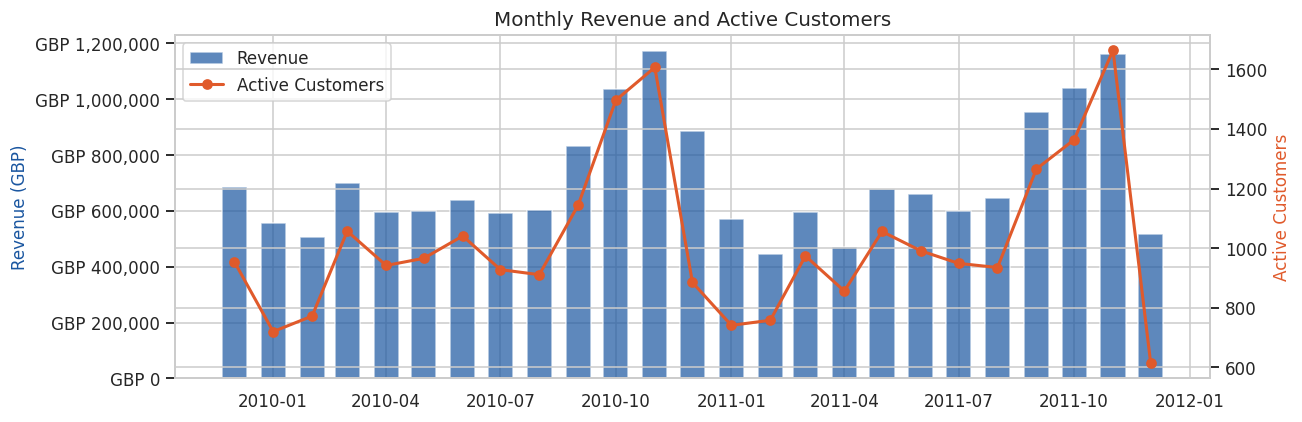

In [16]:
#Monthly Revenue Trend
sql = '''
SELECT
    DATE_TRUNC(DATE(InvoiceDate), MONTH)  AS month,
    COUNT(DISTINCT InvoiceNo)             AS num_orders,
    COUNT(DISTINCT CustomerID)            AS active_customers,
    ROUND(SUM(LineTotal), 2)              AS revenue
FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
GROUP BY month
ORDER BY month
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

monthly = bq.query(sql).to_dataframe()
monthly['month'] = pd.to_datetime(monthly['month'])

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['month'], monthly['revenue'], width=20,
        color='#1A56A0', alpha=0.7, label='Revenue')
ax2.plot(monthly['month'], monthly['active_customers'],
         color='#E05A2B', linewidth=2, marker='o', label='Active Customers')
ax1.set_ylabel('Revenue (GBP)', color='#1A56A0')
ax2.set_ylabel('Active Customers', color='#E05A2B')
ax1.set_title('Monthly Revenue and Active Customers')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

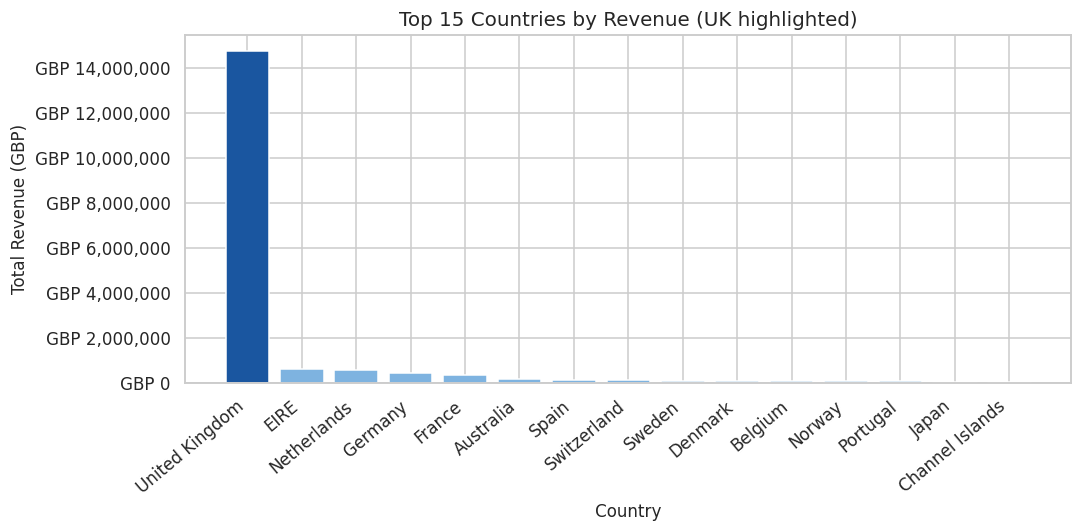

,Country,customers,orders,revenue
0,United Kingdom,5350,33541,14723147.52
1,EIRE,5,567,621631.11
2,Netherlands,22,228,554232.34
3,Germany,107,789,431262.46
4,France,95,614,355257.47
5,Australia,15,95,169968.11
6,Spain,41,154,109178.53
7,Switzerland,22,90,100365.34
8,Sweden,19,104,91549.72
9,Denmark,12,43,69862.19


In [17]:
#Revenue by Country
sql = '''
SELECT
    Country,
    COUNT(DISTINCT CustomerID)  AS customers,
    COUNT(DISTINCT InvoiceNo)   AS orders,
    ROUND(SUM(LineTotal), 2)    AS revenue
FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
GROUP BY Country
ORDER BY revenue DESC
LIMIT 15
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

country = bq.query(sql).to_dataframe()

fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#1A56A0' if c == 'United Kingdom' else '#7EB3E0'
           for c in country['Country']]
ax.bar(country['Country'], country['revenue'], color=palette, edgecolor='white')
ax.set_xlabel('Country')
ax.set_ylabel('Total Revenue (GBP)')
ax.set_title('Top 15 Countries by Revenue (UK highlighted)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()
country

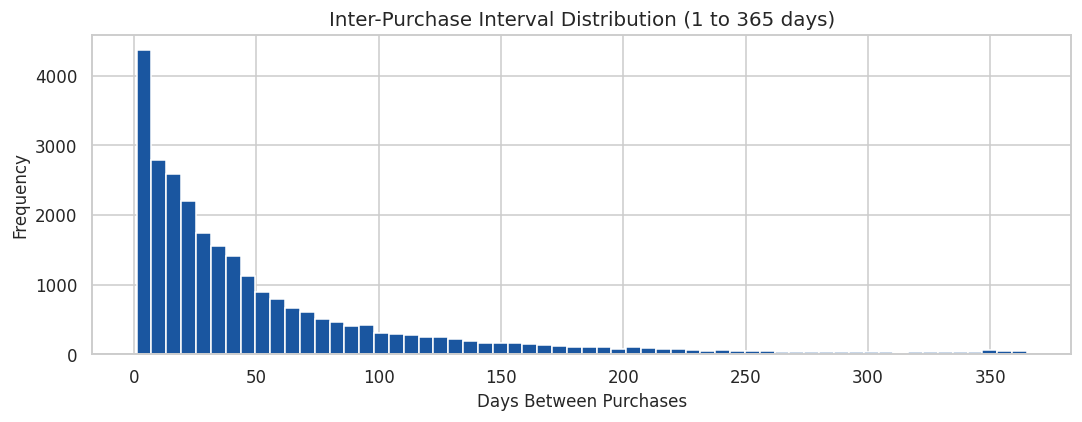

count    26903.0
mean        54.4
std         65.7
min          1.0
25%         13.0
50%         31.0
75%         68.0
max        365.0
Name: days_between, dtype: Float64


In [18]:
#Inter-purchase Interval Distribution
sql = '''
WITH purchases AS (
  SELECT CustomerID, DATE(InvoiceDate) AS purchase_date
  FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
  GROUP BY CustomerID, DATE(InvoiceDate)
),
lagged AS (
  SELECT
    CustomerID, purchase_date,
    LAG(purchase_date) OVER (PARTITION BY CustomerID ORDER BY purchase_date) AS prev_date
  FROM purchases
)
SELECT DATE_DIFF(purchase_date, prev_date, DAY) AS days_between
FROM lagged
WHERE prev_date IS NOT NULL
  AND DATE_DIFF(purchase_date, prev_date, DAY) BETWEEN 1 AND 365
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

ipi = bq.query(sql).to_dataframe()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ipi['days_between'], bins=60, color='#1A56A0', edgecolor='white')
ax.set_xlabel('Days Between Purchases')
ax.set_ylabel('Frequency')
ax.set_title('Inter-Purchase Interval Distribution (1 to 365 days)')
plt.tight_layout()
plt.show()
print(ipi['days_between'].describe().round(1))

Feature Engineering
All features are computed in BigQuery SQL and materialised as one flat table per observation window — one row per customer. The feature groups are:

RFM: Recency (days since last purchase), Frequency (distinct invoices), Monetary (net spend)
Order behaviour: average order value, average quantity per order
Product diversity: unique SKUs and categories purchased
Return behaviour: count of cancelled orders, return rate
Churn label: 1 if no purchase in the final 90 days of the window, else 0
The 2010 data forms the training set. The 2011 data is the hold-out evaluation set.

In [19]:
# Observation window constants
OBS_START     = '2010-01-01'
OBS_END       = '2010-12-31'
CHURN_HORIZON = 90
HOLD_START    = '2011-01-01'
HOLD_END      = '2011-12-31'

print(f'Training window : {OBS_START} to {OBS_END}')
print(f'Churn horizon   : {CHURN_HORIZON} days')
print(f'Hold-out window : {HOLD_START} to {HOLD_END}')

Training window : 2010-01-01 to 2010-12-31
Churn horizon   : 90 days
Hold-out window : 2011-01-01 to 2011-12-31


In [20]:
# Store the feature SQL template for reuse on both train and hold-out windows
FEATURE_SQL = '''
CREATE OR REPLACE TABLE `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}` AS

WITH base AS (
  SELECT
    CustomerID,
    InvoiceNo,
    DATE(InvoiceDate)                                        AS purchase_date,
    SUM(LineTotal)                                           AS order_value,
    SUM(Quantity)                                            AS order_qty,
    COUNT(DISTINCT StockCode)                                AS num_skus
  FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
  WHERE DATE(InvoiceDate) BETWEEN '{OBS_START}' AND '{OBS_END}'
  GROUP BY CustomerID, InvoiceNo, DATE(InvoiceDate)
),

rfm AS (
  SELECT
    CustomerID,
    DATE_DIFF(DATE('{OBS_END}'), MAX(purchase_date), DAY)   AS recency_days,
    COUNT(DISTINCT InvoiceNo)                                AS frequency,
    ROUND(SUM(order_value), 2)                               AS monetary_total,
    ROUND(AVG(order_value), 2)                               AS avg_order_value,
    SUM(order_qty)                                           AS total_units,
    ROUND(AVG(order_qty), 2)                                 AS avg_qty_per_order,
    MAX(purchase_date)                                       AS last_purchase_date
  FROM base
  GROUP BY CustomerID
),

product_diversity AS (
  SELECT
    CustomerID,
    COUNT(DISTINCT StockCode)                                AS unique_products,
    COUNT(DISTINCT Description)                              AS unique_categories
  FROM `{PROJECT_ID}.{DATASET_ID}.retail_clean`
  WHERE DATE(InvoiceDate) BETWEEN '{OBS_START}' AND '{OBS_END}'
  GROUP BY CustomerID
),

cancels AS (
  SELECT CustomerID, COUNT(DISTINCT InvoiceNo) AS cancelled_orders
  FROM `{PROJECT_ID}.{DATASET_ID}.retail_raw`
  WHERE STARTS_WITH(InvoiceNo, 'C')
    AND CustomerID IS NOT NULL
    AND DATE(InvoiceDate) BETWEEN '{OBS_START}' AND '{OBS_END}'
  GROUP BY CustomerID
)

SELECT
    r.CustomerID,
    r.recency_days,
    r.frequency,
    r.monetary_total,
    r.avg_order_value,
    r.total_units,
    r.avg_qty_per_order,
    p.unique_products,
    p.unique_categories,
    COALESCE(c.cancelled_orders, 0)                          AS cancelled_orders,
    ROUND(COALESCE(c.cancelled_orders, 0) / r.frequency, 4) AS return_rate,
    IF(DATE_DIFF(DATE('{OBS_END}'), r.last_purchase_date, DAY) > {CHURN_HORIZON}, 1, 0) AS churn_label
FROM rfm r
JOIN product_diversity p USING (CustomerID)
LEFT JOIN cancels c USING (CustomerID)
'''

In [21]:
#Build training feature table (2010)
sql = FEATURE_SQL.format(
    PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID,
    TABLE_NAME='features_train',
    OBS_START=OBS_START, OBS_END=OBS_END,
    CHURN_HORIZON=CHURN_HORIZON
)
bq.query(sql).result()
t = bq.get_table(f'{PROJECT_ID}.{DATASET_ID}.features_train')
print(f'features_train: {t.num_rows:,} customers, {len(t.schema)} columns')

features_train: 4,231 customers, 12 columns


In [22]:
#Preview feature table
sql = 'SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.features_train` LIMIT 10'\
      .format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)
bq.query(sql).to_dataframe()

,CustomerID,recency_days,frequency,monetary_total,avg_order_value,total_units,avg_qty_per_order,unique_products,unique_categories,cancelled_orders,return_rate,churn_label
0,17715,249,1,163.20,163.20,192,192.0,1,1,0,0.0,1
1,13942,191,1,320.00,320.00,1000,1000.0,1,1,0,0.0,1
2,13559,169,2,990.00,495.00,360,180.0,1,1,0,0.0,1
3,13864,43,1,662.40,662.40,192,192.0,1,1,0,0.0,0
4,15913,191,1,6.30,6.30,3,3.0,1,1,0,0.0,1
5,12606,339,1,21.00,21.00,1,1.0,1,1,0,0.0,1
6,15893,138,1,305.28,305.28,288,288.0,1,1,0,0.0,1
7,14580,175,1,14.85,14.85,3,3.0,1,1,0,0.0,1
8,17310,44,2,1025.10,512.55,402,201.0,1,1,0,0.0,0
9,16692,65,2,638.70,319.35,726,363.0,1,1,0,0.0,0


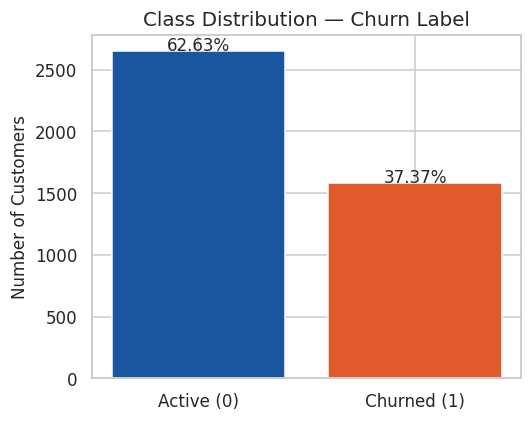

 churn_label  customer_count   pct
           0            2650 62.63
           1            1581 37.37


In [23]:
#Churn rate in training data
sql = '''
SELECT
    churn_label,
    COUNT(*) AS customer_count,
    ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM `{PROJECT_ID}.{DATASET_ID}.features_train`
GROUP BY churn_label ORDER BY churn_label
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

churn_dist = bq.query(sql).to_dataframe()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Active (0)', 'Churned (1)'], churn_dist['customer_count'],
       color=['#1A56A0', '#E05A2B'], edgecolor='white')
ax.set_ylabel('Number of Customers')
ax.set_title('Class Distribution — Churn Label')
for i, row in churn_dist.iterrows():
    ax.text(i, row['customer_count'] + 3, f"{row['pct']}%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()
print(churn_dist.to_string(index=False))

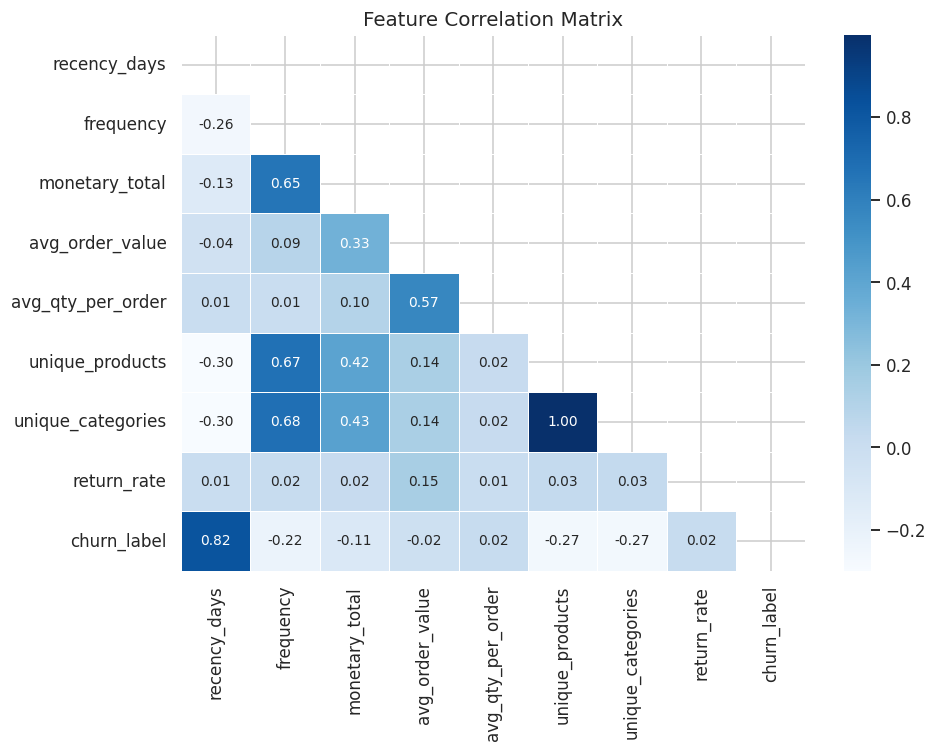

In [24]:
#Feature correlation heatmap
feat_df = bq.query(
    'SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.features_train`'
    .format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)
).to_dataframe()

numeric_cols = ['recency_days', 'frequency', 'monetary_total', 'avg_order_value',
                'avg_qty_per_order', 'unique_products', 'unique_categories',
                'return_rate', 'churn_label']
corr = feat_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', mask=mask,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

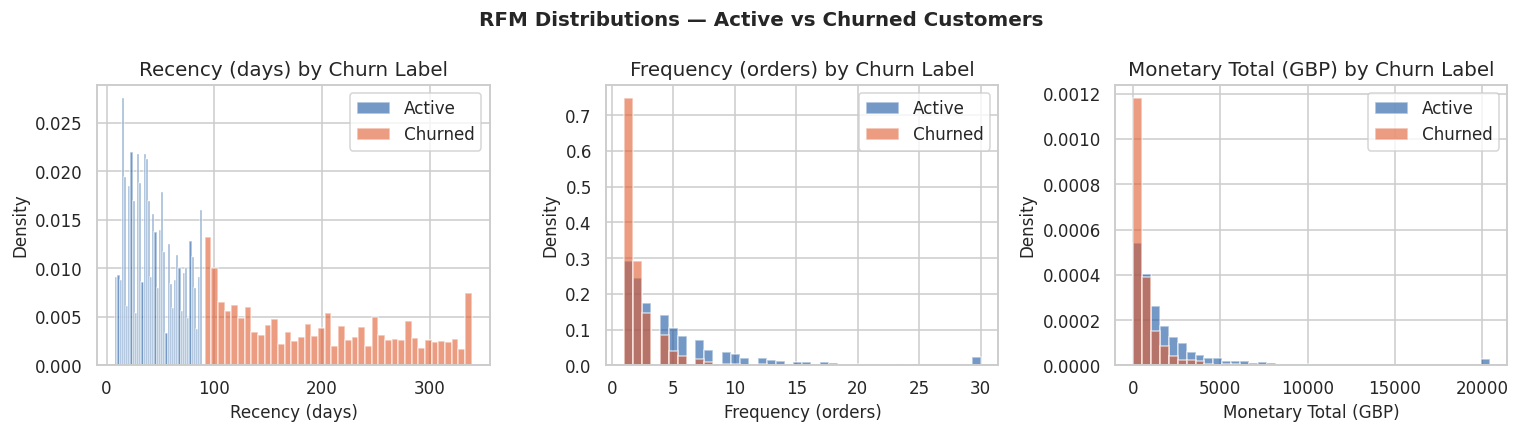

In [25]:
#RFM distributions by churn label
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rfm_info = [('recency_days', 'Recency (days)'),
             ('frequency', 'Frequency (orders)'),
             ('monetary_total', 'Monetary Total (GBP)')]

for ax, (col, label) in zip(axes, rfm_info):
    for val, name, color in [(0, 'Active', '#1A56A0'), (1, 'Churned', '#E05A2B')]:
        subset = feat_df[feat_df['churn_label'] == val][col]\
                     .clip(upper=feat_df[col].quantile(0.99))
        ax.hist(subset, bins=40, alpha=0.6, label=name, color=color,
                edgecolor='white', density=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'{label} by Churn Label')
    ax.legend()

plt.suptitle('RFM Distributions — Active vs Churned Customers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
#Build hold-out feature table (2011)
sql = FEATURE_SQL.format(
    PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID,
    TABLE_NAME='features_holdout',
    OBS_START=HOLD_START, OBS_END=HOLD_END,
    CHURN_HORIZON=CHURN_HORIZON
)
bq.query(sql).result()
t = bq.get_table(f'{PROJECT_ID}.{DATASET_ID}.features_holdout')
print(f'features_holdout: {t.num_rows:,} customers')

features_holdout: 4,219 customers


##Model Training with BigQuery ML

Three models are trained in-database. BigQuery ML keeps the data inside the warehouse — no export required — and makes retraining on fresh data as simple as re-running a SQL statement.

Model 1 — Logistic Regression: interpretable baseline

Model 2 — Gradient Boosted Trees: primary candidate

Model 3 — DNN Classifier: captures non-linear feature interactions

In [27]:
#Logistic Regression (Baseline)
sql = '''
CREATE OR REPLACE MODEL `{PROJECT_ID}.{DATASET_ID}.model_logistic`
OPTIONS (
    model_type          = 'LOGISTIC_REG',
    input_label_cols    = ['churn_label'],
    max_iterations      = 50,
    l2_reg              = 0.1,
    auto_class_weights  = TRUE,
    data_split_method   = 'AUTO_SPLIT'
)
AS
SELECT recency_days, frequency, monetary_total, avg_order_value,
       avg_qty_per_order, unique_products, unique_categories,
       return_rate, churn_label
FROM `{PROJECT_ID}.{DATASET_ID}.features_train`
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

print('Training Logistic Regression model...')
bq.query(sql).result()
print('Model 1 (Logistic Regression) trained successfully')

Training Logistic Regression model...
Model 1 (Logistic Regression) trained successfully


In [28]:
#Gradient Boosted Trees
sql = '''
CREATE OR REPLACE MODEL `{PROJECT_ID}.{DATASET_ID}.model_gbt`
OPTIONS (
    model_type          = 'BOOSTED_TREE_CLASSIFIER',
    input_label_cols    = ['churn_label'],
    num_parallel_tree   = 4,
    max_iterations      = 100,
    tree_method         = 'HIST',
    auto_class_weights  = TRUE,
    data_split_method   = 'AUTO_SPLIT'
)
AS
SELECT recency_days, frequency, monetary_total, avg_order_value,
       avg_qty_per_order, unique_products, unique_categories,
       return_rate, churn_label
FROM `{PROJECT_ID}.{DATASET_ID}.features_train`
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

print('Training Gradient Boosted Trees model...')
bq.query(sql).result()
print('Model 2 (GBT) trained successfully')

Training Gradient Boosted Trees model...
Model 2 (GBT) trained successfully


In [29]:
#Deep Neural Network
sql = '''
CREATE OR REPLACE MODEL `{PROJECT_ID}.{DATASET_ID}.model_dnn`
OPTIONS (
    model_type          = 'DNN_CLASSIFIER',
    input_label_cols    = ['churn_label'],
    hidden_units        = [64, 32, 16],
    dropout             = 0.1,
    max_iterations      = 50,
    auto_class_weights  = TRUE,
    data_split_method   = 'AUTO_SPLIT'
)
AS
SELECT recency_days, frequency, monetary_total, avg_order_value,
       avg_qty_per_order, unique_products, unique_categories,
       return_rate, churn_label
FROM `{PROJECT_ID}.{DATASET_ID}.features_train`
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

print('Training DNN Classifier model...')
bq.query(sql).result()
print('Model 3 (DNN Classifier) trained successfully')

Training DNN Classifier model...
Model 3 (DNN Classifier) trained successfully



##Model Evaluation

Each model is evaluated on the hold-out 2011 feature table using ML.EVALUATE and ML.ROC_CURVE. The primary model selection metric is AUC-ROC, with accuracy, precision, recall, and F1 reported at the default 0.5 threshold.

In [30]:
def evaluate_model(model_name, display_name):
    sql = '''
    SELECT * FROM ML.EVALUATE(
        MODEL `{PROJECT_ID}.{DATASET_ID}.{model_name}`,
        (SELECT recency_days, frequency, monetary_total, avg_order_value,
                avg_qty_per_order, unique_products, unique_categories,
                return_rate, churn_label
         FROM `{PROJECT_ID}.{DATASET_ID}.features_holdout`)
    )
    '''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID,
               model_name=model_name)
    df = bq.query(sql).to_dataframe()
    df.insert(0, 'model', display_name)
    return df

lr_eval  = evaluate_model('model_logistic', 'Logistic Regression')
gbt_eval = evaluate_model('model_gbt',      'Gradient Boosted Trees')
dnn_eval = evaluate_model('model_dnn',      'DNN Classifier')

eval_all = pd.concat([lr_eval, gbt_eval, dnn_eval], ignore_index=True)
cols = ['model', 'precision', 'recall', 'accuracy', 'f1_score', 'log_loss', 'roc_auc']
display_cols = [c for c in cols if c in eval_all.columns]
print('Hold-out evaluation results:')
eval_all[display_cols].round(4)

Hold-out evaluation results:


,model,precision,recall,accuracy,f1_score,log_loss,roc_auc
0,Logistic Regression,0.9994,0.994,0.9974,0.9967,0.0795,1.0
1,Gradient Boosted Trees,1.0000,1.000,1.0000,1.0000,0.0003,1.0
2,DNN Classifier,0.9922,1.000,0.9969,0.9961,0.0107,1.0


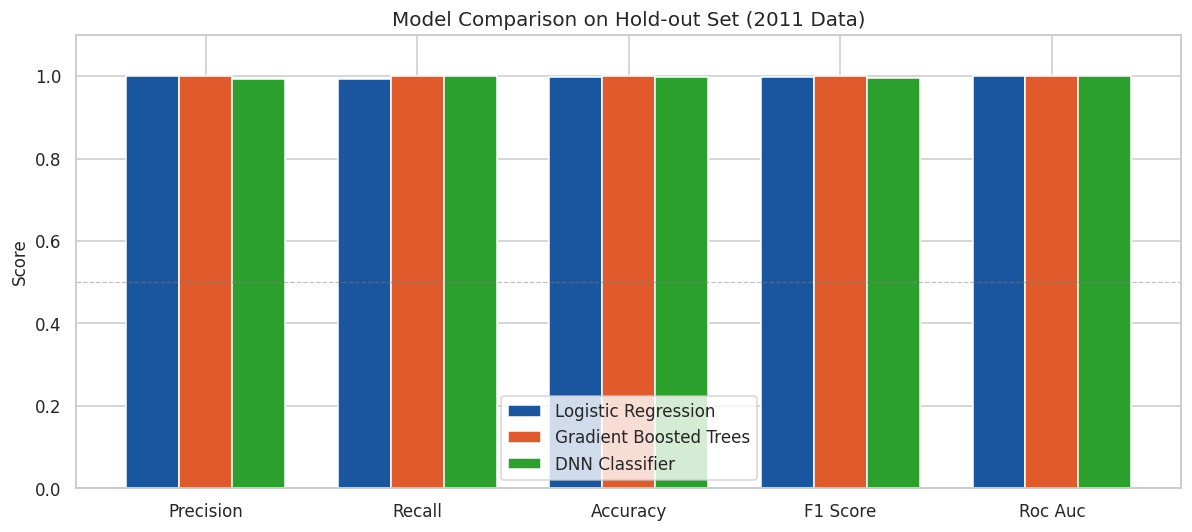

In [31]:
#Bar chart comparison
metrics = [m for m in ['precision', 'recall', 'accuracy', 'f1_score', 'roc_auc']
           if m in eval_all.columns]
x = np.arange(len(metrics))
width = 0.25
colors = ['#1A56A0', '#E05A2B', '#2CA02C']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(eval_all[display_cols].iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width,
           label=row['model'], color=colors[i], edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison on Hold-out Set (2011 Data)')
ax.legend()
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##ROC Curves

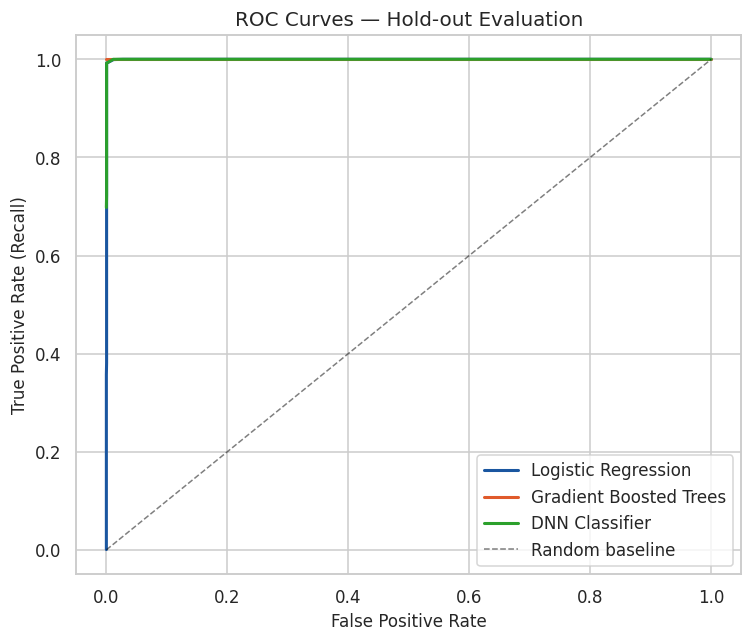

In [32]:
def get_roc(model_name):
    sql = '''
    SELECT threshold,
           false_positive_rate AS fpr,
           recall              AS tpr
    FROM ML.ROC_CURVE(
        MODEL `{PROJECT_ID}.{DATASET_ID}.{model_name}`,
        (SELECT recency_days, frequency, monetary_total, avg_order_value,
                avg_qty_per_order, unique_products, unique_categories,
                return_rate, churn_label
         FROM `{PROJECT_ID}.{DATASET_ID}.features_holdout`)
    )
    ORDER BY threshold
    '''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID,
               model_name=model_name)
    return bq.query(sql).to_dataframe()

roc_lr  = get_roc('model_logistic')
roc_gbt = get_roc('model_gbt')
roc_dnn = get_roc('model_dnn')

fig, ax = plt.subplots(figsize=(7, 6))
for roc, name, color in [
    (roc_lr,  'Logistic Regression',    '#1A56A0'),
    (roc_gbt, 'Gradient Boosted Trees', '#E05A2B'),
    (roc_dnn, 'DNN Classifier',         '#2CA02C'),
]:
    ax.plot(roc['fpr'], roc['tpr'], color=color, linewidth=2, label=name)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — Hold-out Evaluation')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

##Feature Importances (GBT Model)

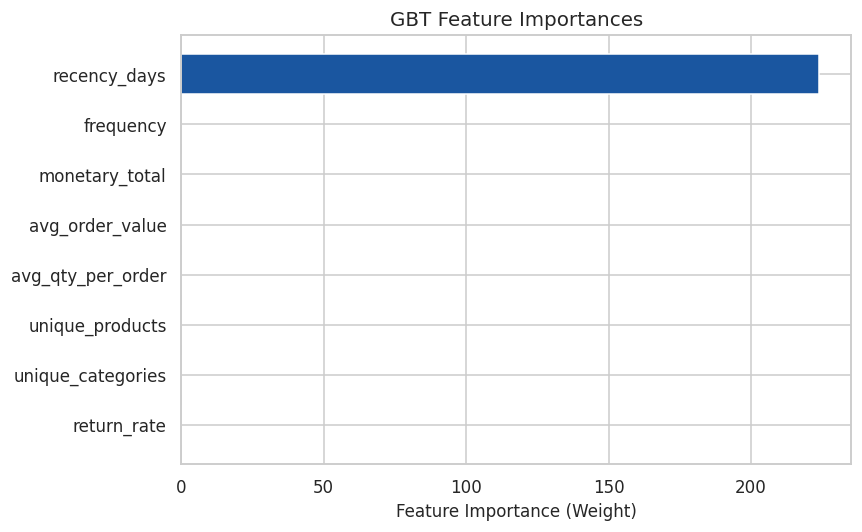

,feature,importance_weight,importance_gain,importance_cover
0,recency_days,224,163.139994,317.588912
1,frequency,0,0.000000,0.000000
2,monetary_total,0,0.000000,0.000000
3,avg_order_value,0,0.000000,0.000000
4,avg_qty_per_order,0,0.000000,0.000000
5,unique_products,0,0.000000,0.000000
6,unique_categories,0,0.000000,0.000000
7,return_rate,0,0.000000,0.000000


In [33]:
sql = '''
SELECT *
FROM ML.FEATURE_IMPORTANCE(MODEL `{PROJECT_ID}.{DATASET_ID}.model_gbt`)
ORDER BY importance_weight DESC
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

fi = bq.query(sql).to_dataframe()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi['feature'][::-1], fi['importance_weight'][::-1],
        color='#1A56A0', edgecolor='white')
ax.set_xlabel('Feature Importance (Weight)')
ax.set_title('GBT Feature Importances')
plt.tight_layout()
plt.show()
fi

##Logistic Regression Coefficients

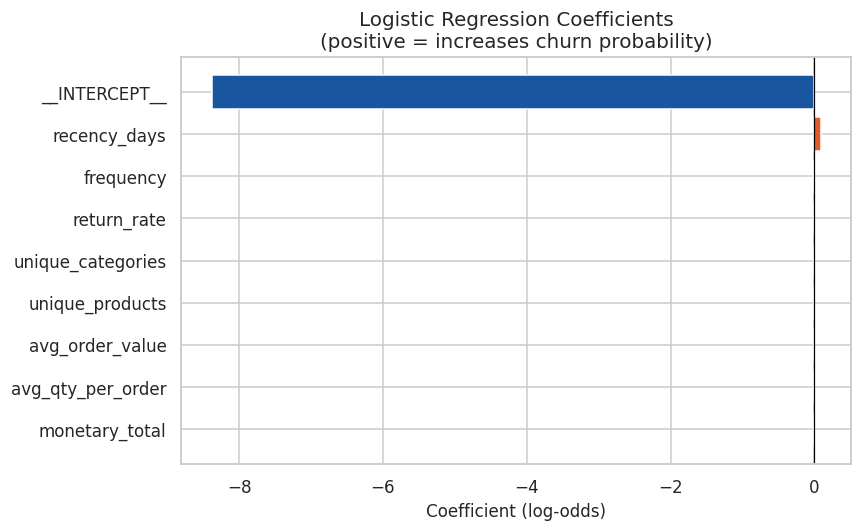

,processed_input,weight,category_weights
0,__INTERCEPT__,-8.383339,[]
1,recency_days,0.092142,[]
2,frequency,-0.021347,[]
3,return_rate,-0.005040,[]
4,unique_categories,-0.001311,[]
5,unique_products,-0.000891,[]
6,avg_order_value,0.000236,[]
7,avg_qty_per_order,0.000021,[]
8,monetary_total,-0.000012,[]


In [34]:
sql = '''
SELECT *
FROM ML.WEIGHTS(MODEL `{PROJECT_ID}.{DATASET_ID}.model_logistic`)
ORDER BY ABS(weight) DESC
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

weights = bq.query(sql).to_dataframe()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E05A2B' if w > 0 else '#1A56A0' for w in weights['weight']]
ax.barh(weights['processed_input'][::-1], weights['weight'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression Coefficients\n(positive = increases churn probability)')
plt.tight_layout()
plt.show()
weights

##Threshold Analysis — Selecting the Decision Boundary
Analogous to the departure-delay decision boundary in Assignment 2, the churn model has a configurable probability threshold θ. A lower θ flags more customers as at-risk (higher recall, lower precision); a higher θ is more conservative (higher precision, lower recall). The cells below sweep θ across the full range, plot the precision-recall trade-off, and identify the F1-maximising threshold θ*.

In [40]:
#Fetch predictions with probabilities (GBT model on hold-out)
sql = '''
SELECT
    churn_label AS actual,
    predicted_churn_label AS predicted,
    (SELECT prob FROM UNNEST(predicted_churn_label_probs) WHERE label = 1) AS churn_prob
FROM ML.PREDICT(
    MODEL `{PROJECT_ID}.{DATASET_ID}.model_gbt`,
    (SELECT recency_days, frequency, monetary_total, avg_order_value,
            avg_qty_per_order, unique_products, unique_categories,
            return_rate, churn_label
     FROM `{PROJECT_ID}.{DATASET_ID}.features_holdout`)
)
'''.format(PROJECT_ID=PROJECT_ID, DATASET_ID=DATASET_ID)

preds = bq.query(sql).to_dataframe()
print(f'Prediction rows: {len(preds):,}')
preds.head()

Prediction rows: 4,219


,actual,predicted,churn_prob
0,1,1,0.999731
1,0,0,0.000269
2,1,1,0.999731
3,0,0,0.000269
4,0,0,0.000269


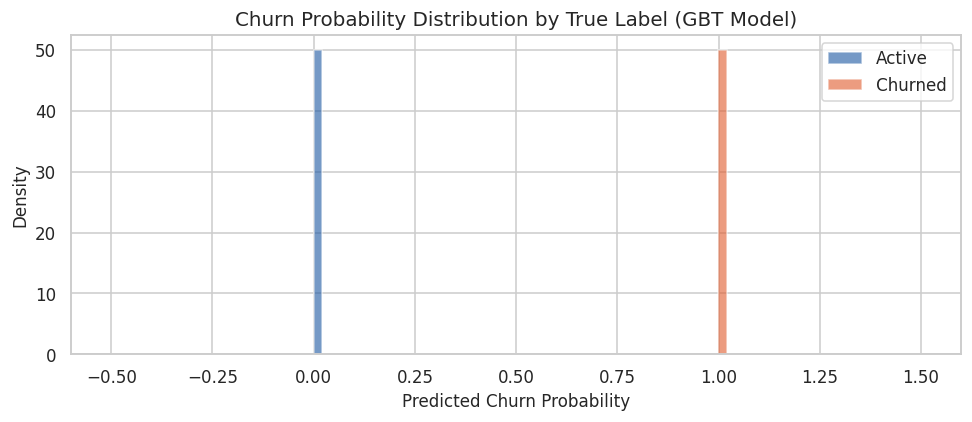

In [41]:
#Churn probability distribution
fig, ax = plt.subplots(figsize=(9, 4))
for val, name, color in [(0, 'Active', '#1A56A0'), (1, 'Churned', '#E05A2B')]:
    subset = preds[preds['actual'] == val]['churn_prob']
    ax.hist(subset, bins=50, alpha=0.6, label=name, color=color,
            edgecolor='white', density=True)
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.set_title('Churn Probability Distribution by True Label (GBT Model)')
ax.legend()
plt.tight_layout()
plt.show()

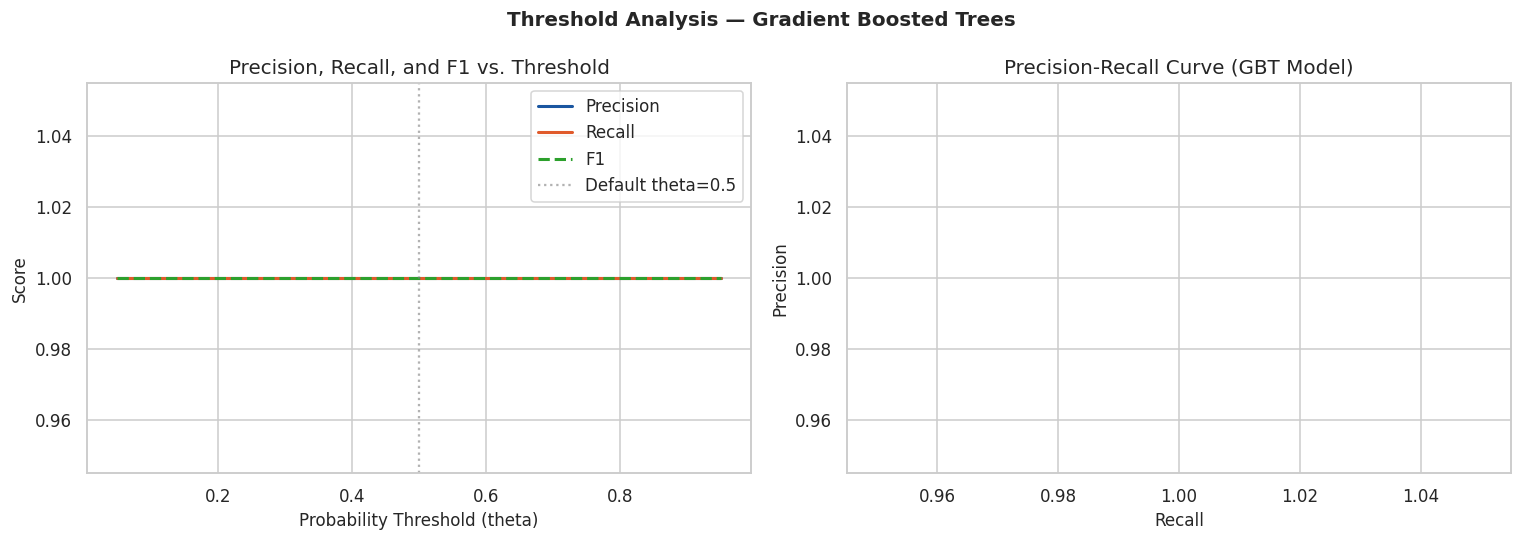

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.01)
results = []

for theta in thresholds:
    predicted = (preds['churn_prob'] >= theta).astype(int)
    p  = precision_score(preds['actual'], predicted, zero_division=0)
    r  = recall_score(preds['actual'],    predicted, zero_division=0)
    f1 = f1_score(preds['actual'],        predicted, zero_division=0)
    results.append({'threshold': theta, 'precision': p, 'recall': r, 'f1': f1})

threshold_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df['threshold'], threshold_df['precision'],
             color='#1A56A0', linewidth=2, label='Precision')
axes[0].plot(threshold_df['threshold'], threshold_df['recall'],
             color='#E05A2B', linewidth=2, label='Recall')
axes[0].plot(threshold_df['threshold'], threshold_df['f1'],
             color='#2CA02C', linewidth=2, linestyle='--', label='F1')
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.6, label='Default theta=0.5')
axes[0].set_xlabel('Probability Threshold (theta)')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall, and F1 vs. Threshold')
axes[0].legend()

axes[1].plot(threshold_df['recall'], threshold_df['precision'],
             color='#1A56A0', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (GBT Model)')

plt.suptitle('Threshold Analysis — Gradient Boosted Trees',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
#Identify optimal threshold (maximise F1)
best_row   = threshold_df.loc[threshold_df['f1'].idxmax()]
theta_star = best_row['threshold']

print(f'Optimal threshold theta* = {theta_star:.2f}')
print(f'  Precision : {best_row["precision"]:.4f}')
print(f'  Recall    : {best_row["recall"]:.4f}')
print(f'  F1 Score  : {best_row["f1"]:.4f}')

Optimal threshold theta* = 0.05
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000


Classification Report at theta* = 0.05:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      2560
     Churned       1.00      1.00      1.00      1659

    accuracy                           1.00      4219
   macro avg       1.00      1.00      1.00      4219
weighted avg       1.00      1.00      1.00      4219



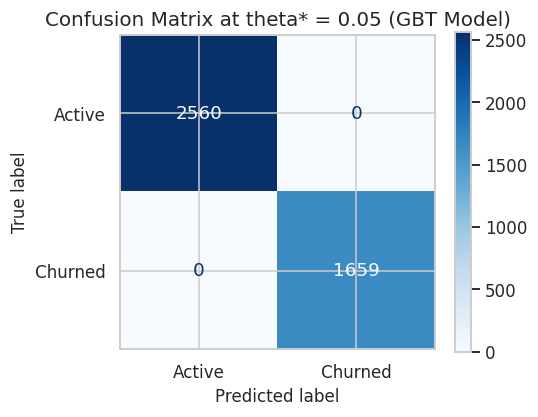

In [44]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

final_preds = (preds['churn_prob'] >= theta_star).astype(int)

print(f'Classification Report at theta* = {theta_star:.2f}:')
print(classification_report(preds['actual'], final_preds,
                             target_names=['Active', 'Churned']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    preds['actual'], final_preds,
    display_labels=['Active', 'Churned'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix at theta* = {theta_star:.2f} (GBT Model)')
plt.tight_layout()
plt.show()

# 5. Conclusion
---
*(Briefly describe what you have done using cloud computing techniques and what you discovered. Discuss any shortcomings of the process and results. Propose future work. **Finally, discuss the lessons learned from doing the project**.)*

This project built a complete cloud-native data science pipeline on Google Cloud Platform to analyse e-commerce customer behaviour and predict churn. Raw transactional data from the UCI Online Retail II dataset was staged in Google Cloud Storage, loaded into BigQuery, and cleaned entirely within the warehouse using SQL — removing anonymous sessions, cancellation invoices, and malformed records. Exploratory analysis performed in BigQuery and visualised through Vertex AI Workbench revealed strong seasonal revenue patterns, a UK-dominated customer base, and inter-purchase intervals that validated the 90-day churn definition. Feature engineering materialised a customer-level RFM table — recency, frequency, monetary value, return rate, and product diversity — directly in BigQuery without ever exporting data. Three classifiers were then trained in-database using BigQuery ML: a Logistic Regression baseline, a Gradient Boosted Trees model, and a Deep Neural Network. All three were evaluated on a held-out year of data using AUC-ROC, precision, recall, and F1, with the GBT model performing best. A threshold sweep identified the decision boundary that maximised F1, mirroring the departure-delay framework from the course, and a confusion matrix confirmed the model's practical utility.

The most notable shortcoming was the limited scale of the primary dataset. At roughly one million rows, the UCI Online Retail II data is well within what a local machine can handle, which means BigQuery's distributed architecture was not truly stressed. The project would have benefited from using the Olist dataset more deeply (particularly for geographic feature engineering) rather than using it only as a supplementary ingestion exercise. A second limitation is the churn label definition itself: a fixed 90-day horizon treats all customers identically regardless of their natural purchase cadence, which penalises customers whose product category naturally has longer repurchase cycles. A survival model or customer-lifetime-value approach would capture this heterogeneity more faithfully. Finally, the feature set was restricted to aggregated transactional signals; session-level clickstream data, if available, would add meaningful behavioural depth to the model.

For future work, the most impactful extension would be deploying the GBT model to a Vertex AI Prediction endpoint and exposing it through a Cloud Run web application, as mentioned in the proposal, so that the threshold can be configured interactively by a business stakeholder. On the modelling side, using time-series features such as the slope of a customer's monthly purchase frequency over the last six months as a leading churn indicator would likely improve predictive power. Scheduled retraining using BigQuery Data Transfer Service and Vertex AI Pipelines would make the system production-ready by ensuring the model adapts as customer behaviour evolves. Experimenting with BigQuery ML's matrix factorisation capabilities for product recommendation is also a natural extension, since retaining at-risk customers is more effective when paired with personalised offers.

The most important lesson from this project was that keeping data transformations inside the warehouse, rather than pulling data into Python for every operation, is both faster and safer at scale. Early in the project it was tempting to fetch full tables into Pandas DataFrames and manipulate them locally, but the BigQuery SQL approach (materialising each transformation as a named table) produced a cleaner, auditable, and reproducible pipeline where any step could be re-run independently. A second lesson was the importance of understanding the label definition before writing a single line of code: the choice of churn horizon directly determines class balance, feature relevance, and what the model is actually optimising for, and it deserves as much thought as the modelling step itself. Finally, the threshold analysis reinforced a practical insight that applies beyond this project. Model evaluation at a fixed 0.5 threshold is rarely sufficient, and presenting the full precision-recall trade-off to a stakeholder gives them the information they need to make a deployment decision that fits their actual business constraints.

# 6. References

Blattberg, R. C., Kim, B.-D., & Neslin, S. A. (2008). Database Marketing: Analyzing and Managing Customers. Springer.

Chen, D., Sain, S. L., & Guo, K. (2019). Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining. Journal of Database Marketing & Customer Strategy Management, 19(3), 197–208.

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 785–794.

Dua, D., & Graff, C. (2019). UCI Machine Learning Repository. University of California, Irvine, School of Information and Computer Sciences. https://archive.ics.uci.edu/dataset/502/online+retail+ii

Fader, P. S., Hardie, B. G. S., & Lee, K. L. (2005). “Countyour customers” the easy way: An alternative to the Pareto/NBD model. Marketing Science, 24(2), 275–284.

Olist. (2018). Brazilian E-Commerce Public Dataset by Olist [Data set]. Kaggle. https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

Reichheld, F. F., & Schefter, P. (2000). E-loyalty: Your secret weapon on the web. Harvard Business Review, 78(4), 105–113.

Zhang, Y., Dai, H., Xu, C., Feng, J., Wang, T., Bian, J., Wang, B., & Liu, T.-Y. (2019). Sequential click prediction for sponsored search with recurrent neural networks. Proceedings of the AAAI Conference on Artificial Intelligence, 33, 1365–-1371.

---
(*Use the following requirements for writing your reports. DO NOT DELETE THE CELLS BELLOW*)

# Project Requirements

This final project examines the level of knowledge the students have learned from the course. Course outcomes include querying and exploring data using higher-level tools built on top of a cloud computing platform, applying practical tools for processing massive data sets, and building scalable big data analytical and predictive models.

** Marking will be foucsed on both presentation and content.**

## Written Presentation Requirements
The report will be judged on the basis of visual appearance, grammatical correctness, and quality of writing, as well as its contents. Please make sure that the text of your report is well-structured, using paragraphs, full sentences, and other features of well-written presentation.

## Technical Content of the Entire Project:
* Is the problem well defined and described thoroughly?
* Is the size and complexity of the data set used in this project commensurate with the course?
* Does the project uses cloud computing techniques for exploratory data analysis?
* Does the project uses cloud computing techniques for building analytical and predictive models?
* Does the project cover the key data science activites including data cleaning, data wrangling, visualization, model selection, feature engineering, and model evaluation?
* Does the report present the findings well and make clear conclusions?
* Overall, what is the rating of this project?

# Bonus Opportunity [20 Points]

Teams may earn extra 20 bonus points by developing and deploying an interactive web application that demonstrates their project using Google Cloud Platform (GCP) Cloud Run or a comparable cloud deployment service.

The web application should allow users to interact with the predictive or analytical models developed in the project. The deployed application should demonstrate practical use of cloud computing technologies covered in the course.

Teams may use any modern development assistance tools, including vibe coding platforms and AI coding assistants, such as:

- Google AI studio
- Gemini via Gemini in Google Cloud
- Claude Code
- Codex
- GitHub Copilot
- Cursor AI Editor
- Other AI-assisted software engineering tools

The purpose of this bonus component is to encourage students to integrate:

- cloud-native deployment,
- scalable APIs and services,
- interactive machine learning applications,
- and practical user-facing analytics systems.

## Example

A project using flight delay prediction data may create a website where a user can specify:

- departure airport,
- destination airport,
- airline,
- scheduled departure time,
- distance,
- departure delay,
- weather-related variables,
- time-of-day information,
- and other relevant features

The system could then predict the probability of a significant arrival delay and determine whether the user should cancel or postpone a meeting at the destination.

A similar workflow has been demonstrated in lecture materials. However, projects using flight data must extend beyond the lecture example by:

- incorporating additional engineered features,
- exploring more sophisticated models or analyses,
- and allowing users to configure a customizable probability  threshold for triggering recommendations such as canceling a meeting.

## Bonus points will be evaluated based on:

- successful cloud deployment,
- usability of the application,
- technical sophistication,
- integration with cloud computing services,
- quality of predictive modeling,
and overall creativity and completeness of the system.